<a href="https://colab.research.google.com/github/adithya0x/Optimal-Portfolio-Allocation/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week-1 Assignment
Fill the missing places wherever TO DO is mentioned and also understnad what has been done properly

Also report :
- Asset with highest expected return:
- Asset with highest volatility:
- If there is any negatively correlated pairs (corr < -0.1) and if yes also mention which are they

Do not use Chatgpt . It is a simple assignment. Make a copy of this colab notebook and do your changes and submit it as `Assignment1_yourrollno.ipnyb`


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt


In [2]:
TICKERS = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']  # you can change these take any 3 assets that are in yfinance
print("Selected assets:", TICKERS)


Selected assets: ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']


In [4]:
prices = yf.download(TICKERS, period="3y") #downlaod data of 3yrs
prices = prices.xs('Close', axis=1, level=0)
prices = prices.ffill().dropna()

prices.tail(10)

/tmp/ipykernel_5480/1521813061.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(TICKERS, period="3y") #downlaod data of 3yrs
[*********************100%***********************]  3 of 3 completed


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Date,,,
2026-04-24,784.849976,1327.800049,2396.899902
2026-04-27,789.799988,1365.800049,2447.600098
2026-04-28,782.549988,1388.900024,2444.699951
2026-04-29,779.000000,1425.400024,2474.699951
2026-04-30,771.700012,1430.800049,2473.899902
2026-05-01,771.700012,1430.800049,2473.899902
2026-05-04,779.400024,1463.099976,2431.300049
2026-05-05,772.299988,1463.599976,2427.300049
2026-05-06,796.549988,1437.900024,2435.399902


In [5]:
simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

print("\nSimple Returns :")
display(simple_returns.head(10))

print("\nLog Returns :")
display(log_returns.head(10))


Simple Returns :


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Date,,,
2023-05-09,0.000030,0.003095,0.010044
2023-05-10,0.004622,0.006876,0.001081
2023-05-11,0.000666,-0.006529,-0.001415
2023-05-12,0.008831,0.001633,-0.002392
2023-05-15,0.004797,0.001972,-0.005879
2023-05-16,-0.005734,-0.014241,0.000952
2023-05-17,-0.005373,-0.005909,-0.015177
2023-05-18,0.003998,-0.002152,-0.002758
2023-05-19,0.001155,0.003246,0.007188



Log Returns :


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Date,,,
2023-05-09,0.000030,0.003090,0.009994
2023-05-10,0.004611,0.006853,0.001081
2023-05-11,0.000666,-0.006550,-0.001416
2023-05-12,0.008793,0.001631,-0.002395
2023-05-15,0.004785,0.001970,-0.005896
2023-05-16,-0.005750,-0.014344,0.000952
2023-05-17,-0.005387,-0.005927,-0.015294
2023-05-18,0.003990,-0.002154,-0.002762
2023-05-19,0.001154,0.003240,0.007162


In [6]:
TRADING_DAYS = 252

expected_return = log_returns.mean() * TRADING_DAYS

volatility = log_returns.std() * np.sqrt(TRADING_DAYS)

print("\n Annualized Expected Return")
display(expected_return)

print("\n Annualized Volatility (Risk)")
display(volatility)


 Annualized Expected Return


,0
Ticker,
HDFCBANK.NS,0.002054
RELIANCE.NS,0.082023
TCS.NS,-0.074494



 Annualized Volatility (Risk)


,0
Ticker,
HDFCBANK.NS,0.195328
RELIANCE.NS,0.207316
TCS.NS,0.211006


In [7]:
cov_daily = log_returns.cov()
cov_annual = cov_daily * TRADING_DAYS

corr = log_returns.corr()

print("\n Covariance Matrix (Annualized) ")
display(cov_annual)

print("\n Correlation Matrix ")
display(corr)



 Covariance Matrix (Annualized) 


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Ticker,,,
HDFCBANK.NS,0.038153,0.014665,0.006561
RELIANCE.NS,0.014665,0.042980,0.010981
TCS.NS,0.006561,0.010981,0.044524



 Correlation Matrix 


Ticker,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Ticker,,,
HDFCBANK.NS,1.000000,0.362144,0.159183
RELIANCE.NS,0.362144,1.000000,0.251015
TCS.NS,0.159183,0.251015,1.000000


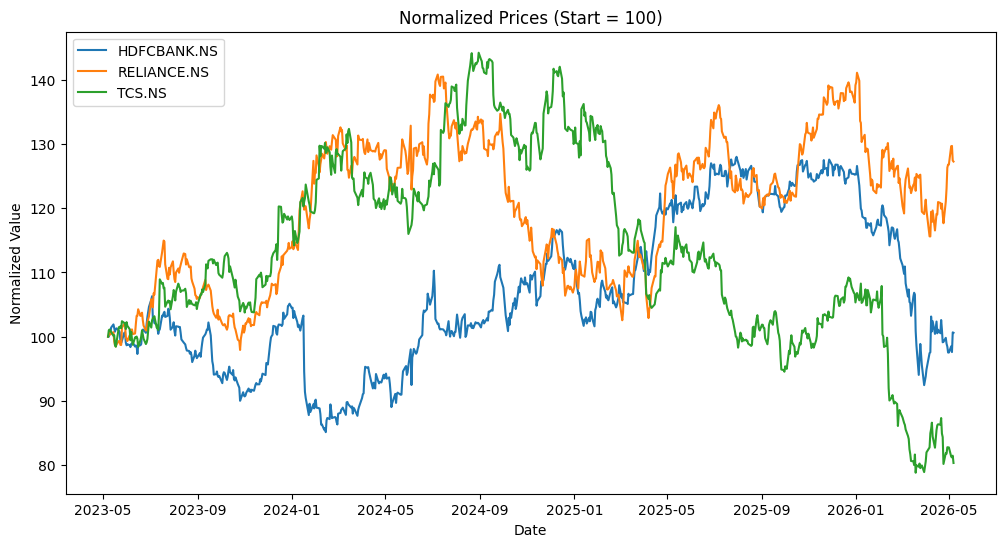

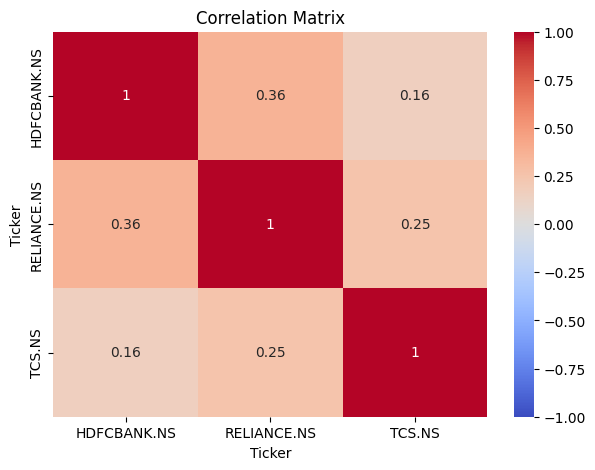

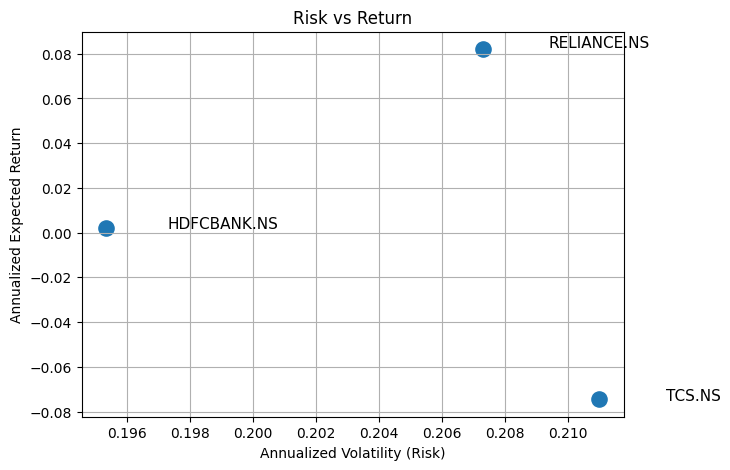

In [8]:
#Visualization
norm_prices = prices / prices.iloc[0] * 100
plt.figure(figsize=(12,6))
for col in norm_prices.columns:
    plt.plot(norm_prices.index, norm_prices[col], label=col)

plt.title("Normalized Prices (Start = 100)")
plt.ylabel("Normalized Value")
plt.xlabel("Date")
plt.legend()
plt.show()

# 2) Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# 3) Risk vs Return Scatter
plt.figure(figsize=(7,5))
plt.scatter(volatility, expected_return, s=120)

for t in TICKERS:
    plt.text(volatility[t]*1.01, expected_return[t]*1.01, t, fontsize=11)

plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Expected Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()